## Steam trajectory - Data visualization

#### After ingesting all the data (the Kaggle set to get the cohort, Steamcharts scraping to get the data) and loading it into the notebook, let's visualize the data. We want to investigate the anomolous "earliest_month_tracked" field as well since it had 2 dates coming up frequently.

In [14]:
%load_ext autoreload
%autoreload 2

import os
os.chdir("/Users/pmacias/Dropbox/steamproject")
print(os.getcwd())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/pmacias/Dropbox/steamproject


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

from steam_trajectory.db.connection import get_connection

conn = get_connection("steam_project.db")

In [16]:
history_df = pd.read_sql("""
    SELECT g.appid, g.name, g.release_date,
           MIN(m.month) AS earliest_tracked_month
    FROM games g
    JOIN monthly_metrics m ON g.appid = m.appid
    GROUP BY g.appid
""", conn)

history_df["release_date_parsed"] = pd.to_datetime(history_df["release_date"], errors="coerce")
history_df["earliest_tracked_parsed"] = pd.to_datetime(history_df["earliest_tracked_month"], errors="coerce")
history_df["gap_months"] = (
    (history_df["earliest_tracked_parsed"] - history_df["release_date_parsed"])
    / pd.Timedelta(days=30.44)
).round(1)

print("Most common earliest_tracked_month values:")
print(history_df["earliest_tracked_month"].value_counts().head(10))

Most common earliest_tracked_month values:
earliest_tracked_month
2022-10-01    10
2020-10-01     8
2020-08-01     7
2020-03-01     7
2021-08-01     7
2019-02-01     6
2019-03-01     6
2021-09-01     6
2019-11-01     6
2020-11-01     6
Name: count, dtype: int64


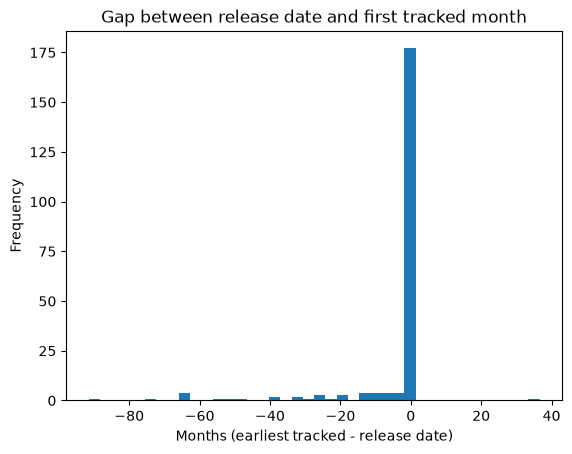

In [17]:
history_df["gap_months"].plot(kind="hist", bins=40, title="Gap between release date and first tracked month")
plt.xlabel("Months (earliest tracked - release date)")
plt.show()

In [18]:
large_gap = history_df[history_df["gap_months"] > 24].sort_values("gap_months", ascending=False)
print(f"{len(large_gap)} games with >24 month gap:")
large_gap[["name", "release_date", "earliest_tracked_month", "gap_months"]]

1 games with >24 month gap:


,name,release_date,earliest_tracked_month,gap_months
186,Isle of Jura,"Feb 11, 2022",2025-03-01,36.6


In [19]:
monthly_df = pd.read_sql("""
    SELECT appid, month, avg_players
    FROM monthly_metrics
    WHERE avg_players IS NOT NULL
    ORDER BY appid, month
""", conn)

monthly_df["month"] = pd.to_datetime(monthly_df["month"])
monthly_df["month_index"] = monthly_df["month"].dt.year * 12 + monthly_df["month"].dt.month
monthly_df["months_since_start"] = monthly_df.groupby("appid")["month_index"].transform(lambda x: x - x.min())

In [20]:
completeness = monthly_df.groupby("appid")["months_since_start"].agg(["min", "max", "count"]).reset_index()
completeness["expected_months"] = completeness["max"] - completeness["min"] + 1
completeness["completeness_pct"] = completeness["count"] / completeness["expected_months"] * 100

print(completeness["completeness_pct"].describe())

count    215.000000
mean      94.758609
std       12.406188
min       40.740741
25%       98.275349
50%      100.000000
75%      100.000000
max      100.000000
Name: completeness_pct, dtype: float64


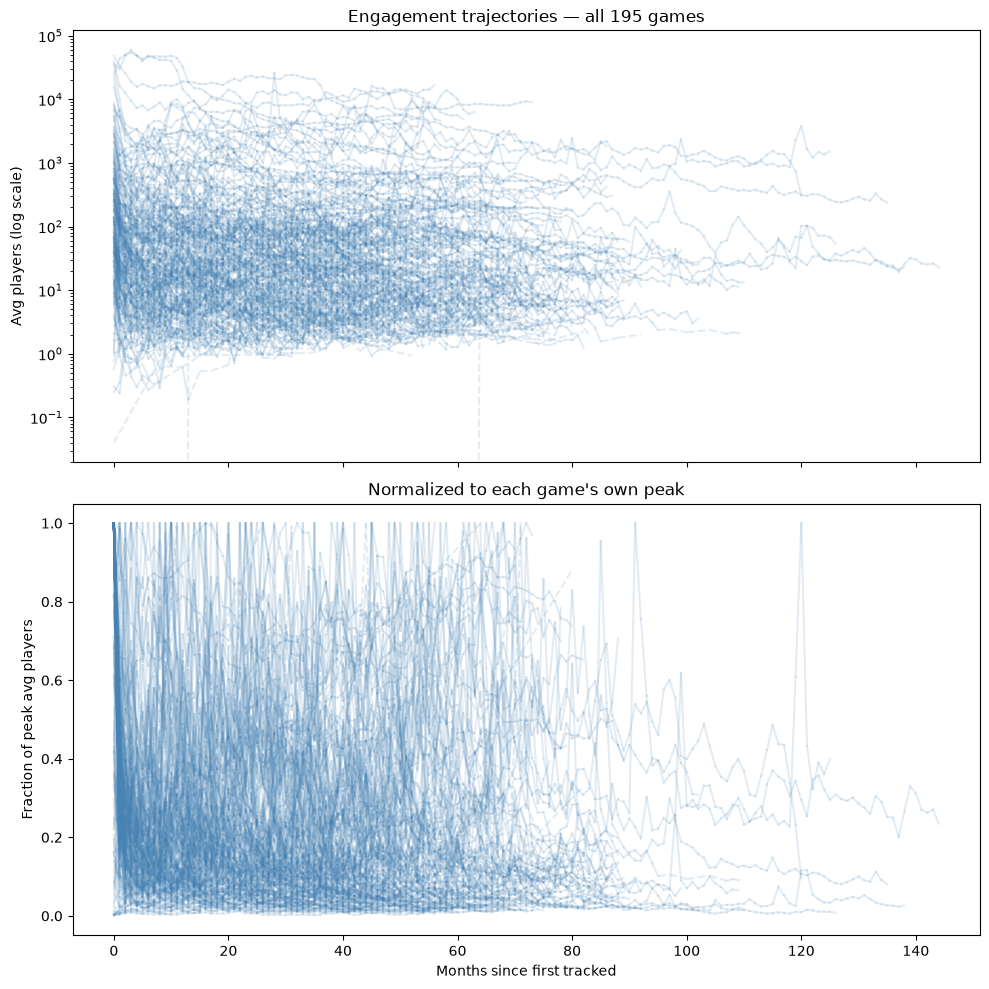

In [21]:
import numpy as np

def plot_with_gaps(ax, x, y, color, alpha):
    """Plots a single game's line, using a dashed segment anywhere
    the underlying months aren't consecutive (a real data gap) and
    a solid segment where they are — so a gap-bridging line reads
    visually as 'we don't know what happened here', not as a
    genuine observed trend."""
    x, y = np.asarray(x), np.asarray(y)
    order = np.argsort(x)
    x, y = x[order], y[order]
    for i in range(len(x) - 1):
        is_gap = (x[i + 1] - x[i]) > 1
        ax.plot(x[i:i+2], y[i:i+2], linestyle="--" if is_gap else "-",
                color=color, alpha=alpha)

peak_per_game = monthly_df.groupby("appid")["avg_players"].transform("max")
monthly_df["normalized_players"] = monthly_df["avg_players"] / peak_per_game

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

for appid, group in monthly_df.groupby("appid"):
    plot_with_gaps(ax1, group["months_since_start"], group["avg_players"], "steelblue", 0.15)
    plot_with_gaps(ax2, group["months_since_start"], group["normalized_players"], "steelblue", 0.15)

ax1.set_yscale("log")
ax1.set_ylabel("Avg players (log scale)")
ax1.set_title("Engagement trajectories — all 195 games")

ax2.set_ylabel("Fraction of peak avg players")
ax2.set_xlabel("Months since first tracked")
ax2.set_title("Normalized to each game's own peak")

plt.tight_layout()
plt.show()

In [22]:
db_appids = set(pd.read_sql("SELECT DISTINCT appid FROM monthly_metrics", conn)["appid"])
cohort_appids = set(pd.read_sql("SELECT appid FROM games", conn)["appid"])

print("Games table has:", len(cohort_appids), "games")
print("In monthly_metrics but not in games table:", db_appids - cohort_appids)
print("In games table but missing from monthly_metrics:", cohort_appids - db_appids)

Games table has: 215 games
In monthly_metrics but not in games table: set()
In games table but missing from monthly_metrics: set()
